In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
data = pd.read_csv('C:\\Users\\Anty Favour\\Documents\\wincosin breast cancer data set.csv')

In [3]:

df= data
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')

In [4]:
df.drop(columns=['Unnamed: 32', 'id'], inplace=True)
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [5]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

QUESTION 1: How Many Malignant VS Benign Cases Do We Have?

In [6]:
df.diagnosis.value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

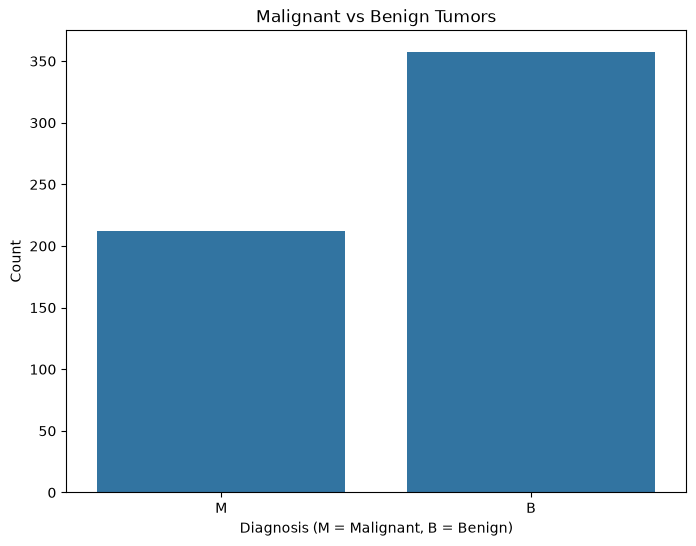

In [7]:
#plotting the count of diagnosis
plt.figure(figsize=(8,6))
sns.countplot(x='diagnosis', data=df)
plt.title('Malignant vs Benign Tumors')
plt.xlabel('Diagnosis (M = Malignant, B = Benign)')
plt.ylabel('Count')
plt.show()

Our graph shows that benign tumour takes up more than 60% with Malignat being less than 40%

QUESTION 2: Which tumor characteristics differ the most between malignant and benign tumors?


i will now check for features that describe the charactristics like radius_mean
perimeter_mean
area_mean
concavity_mean


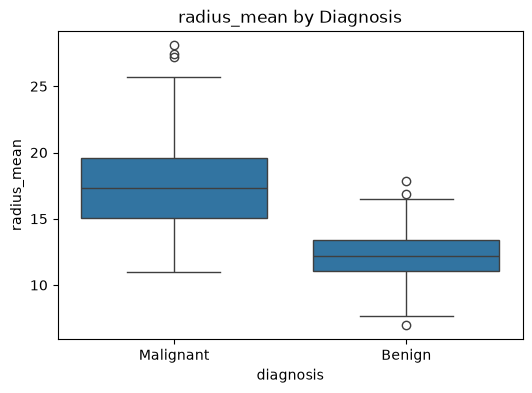

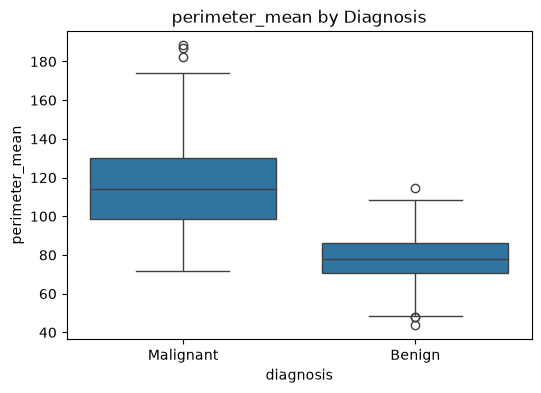

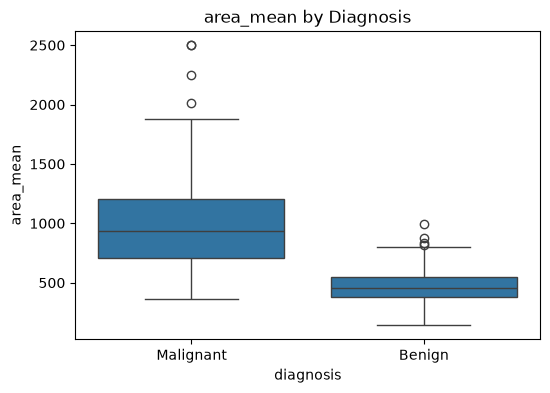

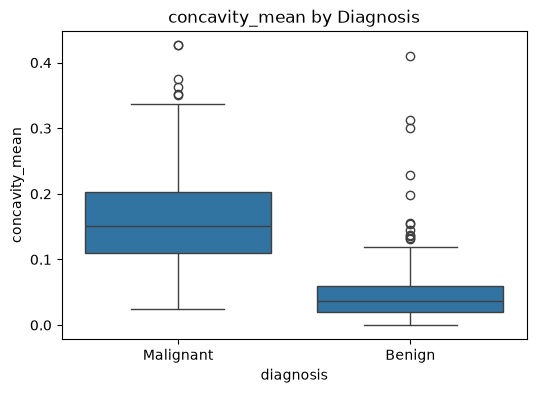

In [10]:
features = ["radius_mean", "perimeter_mean", "area_mean", "concavity_mean"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="diagnosis", y=feature, data=df)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

In [11]:
df["diagnosis"] = df["diagnosis"].replace({
    "M": "Malignant",
    "B": "Benign"
})

The comparison of radius, perimeter, area, and concavity reveals clear differences between malignant and benign tumors. Across all four measurements, malignant tumors consistently exhibit higher median values and greater variability. These findings suggest that malignant tumors are generally larger and have more irregular structural characteristics, making these features valuable for distinguishing between the two diagnoses.

QUESTION 3: Which features are most strongly correlated with breast cancer diagnosis?

Objective

The purpose of this analysis is to identify which tumor characteristics have the strongest relationship with whether a tumor is malignant (cancerous) or benign (non-cancerous).

Understanding these relationships is important because not every tumor measurement contributes equally to diagnosis. Some characteristics provide much stronger evidence of malignancy than others. Identifying these features helps researchers and healthcare professionals focus on the measurements that are most informative when assessing breast tumors.

To perform this analysis, the diagnosis column was converted from categorical values (Malignant and Benign) into numerical values (1 for Malignant and 0 for Benign). This conversion allows correlation analysis to be performed, as correlation measures can only be calculated using numerical data.

Since OUR diagnosis column contains "M" and "B", first convert it to numbers for the correlation analysis:

In [15]:
df["diagnosis"].unique()

<StringArray>
['Malignant', 'Benign']
Length: 2, dtype: str

In [16]:
df["diagnosis_numeric"] = df["diagnosis"].map({
    "Malignant": 1,
    "Benign": 0
})

In [17]:
df[["diagnosis", "diagnosis_numeric"]].head()

,diagnosis,diagnosis_numeric
0,Malignant,1
1,Malignant,1
2,Malignant,1
3,Malignant,1
4,Malignant,1


In [19]:
correlation = df.corr(numeric_only=True)

correlation["diagnosis_numeric"].sort_values(ascending=False)

diagnosis_numeric          1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

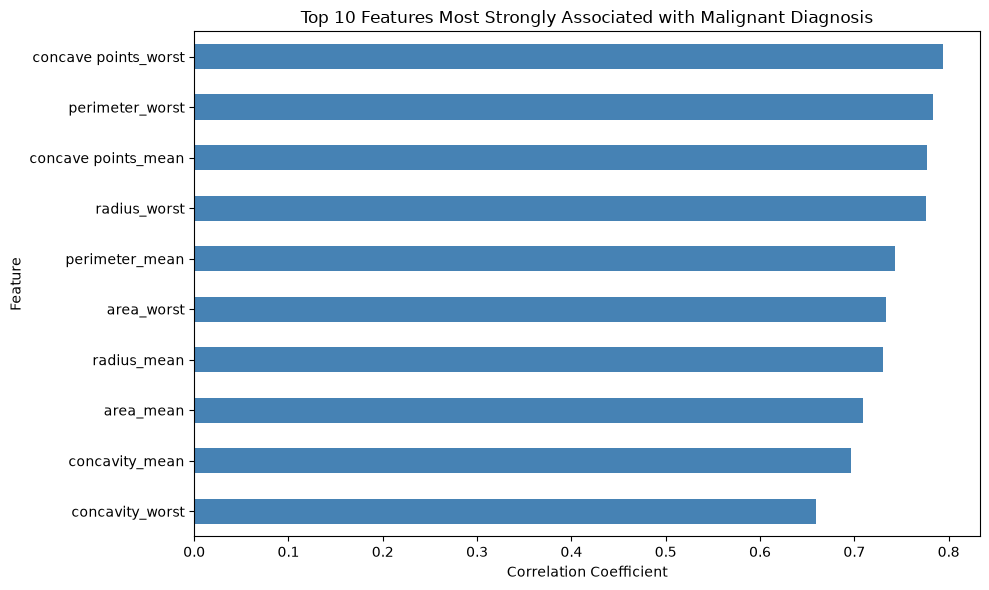

In [20]:
top_features = correlation["diagnosis_numeric"].sort_values(ascending=False)[1:11]

plt.figure(figsize=(10,6))
top_features.sort_values().plot(kind="barh", color="steelblue")

plt.title("Top 10 Features Most Strongly Associated with Malignant Diagnosis")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The results suggest that tumor size and tumor shape are the strongest indicators of malignancy.

Measurements such as radius, perimeter, and area describe the overall size of a tumor. The larger these measurements become, the more likely a tumor is to be malignant.

Similarly, concavity and concave points describe how irregular or uneven the edges of a tumor are. Malignant tumors often have rough, jagged boundaries, while benign tumors usually have smoother, more regular shapes. This explains why these features have some of the highest correlation values.

An interesting observation is that many of the strongest predictors end with the word "worst."

In this dataset, worst does not mean "bad." Instead, it represents the largest or most extreme measurement recorded for that feature. These extreme measurements appear to separate malignant tumors from benign ones more effectively than the average measurements.

For example:
radius_mean represents the average tumor radius.
radius_worst represents the largest radius measured.

The stronger correlation of the worst measurements suggests that extreme tumor characteristics provide more useful information when identifying malignant tumors.

Key Insight

The three strongest predictors of malignancy were:

Concave Points (Worst)
Perimeter (Worst)
Concave Points (Mean)

Each of these features had a correlation above 0.77, indicating a very strong relationship with malignant diagnosis.

This suggests that tumors with larger sizes and more irregular boundaries are considerably more likely to be malignant.

Question 4: Which Features Are Most Related to Each Other?

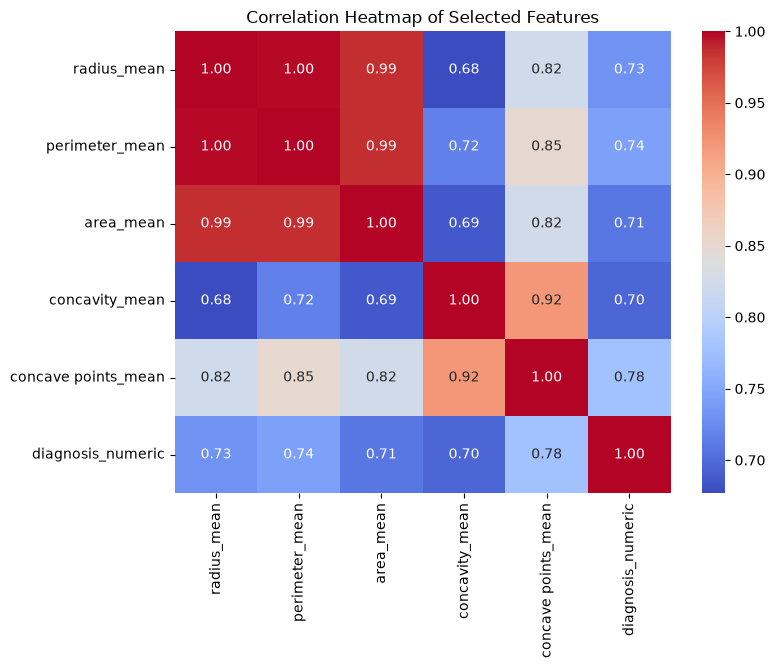

In [21]:
# Select the important variables
selected_features = [
    "radius_mean",
    "perimeter_mean",
    "area_mean",
    "concavity_mean",
    "concave points_mean",
    "diagnosis_numeric"
]

corr_matrix = df[selected_features].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

In [22]:
corr_matrix.round(2)

,radius_mean,perimeter_mean,area_mean,concavity_mean,concave points_mean,diagnosis_numeric
radius_mean,1.00,1.00,0.99,0.68,0.82,0.73
perimeter_mean,1.00,1.00,0.99,0.72,0.85,0.74
area_mean,0.99,0.99,1.00,0.69,0.82,0.71
concavity_mean,0.68,0.72,0.69,1.00,0.92,0.70
concave points_mean,0.82,0.85,0.82,0.92,1.00,0.78
diagnosis_numeric,0.73,0.74,0.71,0.70,0.78,1.00


Interpretation

The heatmap shows how strongly different tumor characteristics are related to each other and to the breast cancer diagnosis. The darker red colors indicate stronger positive relationships, meaning those features tend to increase together.

The results show that radius, perimeter, and area are almost perfectly correlated, meaning that as a tumor becomes larger, its perimeter and area also increase. This is expected because these measurements all describe the size of the tumor.

The heatmap also shows a very strong relationship between concavity and concave points, indicating that tumors with more irregular borders usually have more concave points. These irregular shapes are commonly associated with malignant (cancerous) tumors.

Among the selected features, concave points has the strongest relationship with the diagnosis, suggesting that it is one of the most useful measurements for distinguishing malignant tumors from benign ones. Overall, the analysis shows that both the size and shape of a tumor are important indicators in breast cancer diagnosis, with larger and more irregular tumors being more likely to be malignant.